<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #7c3aed; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Reglas de Asociación: Apriori y FP-Growth 🛒
      </h1>
      <p style="margin: 6px 0 0 0; color: #7c3aed; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Market Basket Analysis — Apriori & FP-Growth
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 03 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/04_Reglas_de_Asociacion_Apriori_y_FP_Growth.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Las Tres Métricas Fundamentales de Reglas de Asociación 📊

Una **regla de asociación** tiene la forma $X \Rightarrow Y$ (antecedente $X$ implica consecuente $Y$).

| Métrica | Fórmula | Significado Práctico |
|---------|---------|---------------------|
| **Soporte** | $\text{supp}(X) = P(X) = \frac{|T_X|}{|T|}$ | Frecuencia relativa de $X$ en todas las transacciones |
| **Confianza** | $\text{conf}(X \Rightarrow Y) = P(Y|X) = \frac{P(X \cup Y)}{P(X)}$ | Probabilidad de $Y$ dado $X$. Si compra $X$, ¿qué tan probable es que compre $Y$? |
| **Lift** | $\text{lift}(X \Rightarrow Y) = \frac{P(X \cup Y)}{P(X) \cdot P(Y)}$ | Factor de amplificación respecto a independencia. Lift > 1 indica asociación positiva |

### 1.1 Algoritmo Apriori (Agrawal & Srikant, 1994)

Explota la **propiedad Apriori** (*anti-monotonicidad del soporte*):

> Si un itemset es frecuente, todos sus subconjuntos también son frecuentes.  
> Equivalentemente: si un itemset es infrecuente, ningún superconjunto puede ser frecuente.

Esto permite podar el espacio de búsqueda exponencialmente. Sin embargo, puede generar muchos candidatos en datasets densos.

### 1.2 FP-Growth (Han et al., 2000)

Evita la generación de candidatos usando un **FP-Tree** (árbol de patrones frecuentes):
1. Construye el árbol con dos pasadas sobre los datos.
2. Extrae patrones directamente del árbol mediante minería condicional recursiva.

**Ventajas de FP-Growth:** sin generación de candidatos, más eficiente en memoria, típicamente $10\text{–}100\times$ más rápido que Apriori en datasets grandes.

### 1.3 Interpretación del Lift

| Lift | Interpretación |
|------|---------------|
| Lift = 1 | $X$ e $Y$ son estadísticamente independientes |
| Lift > 1 | Asociación positiva: comprar $X$ aumenta la probabilidad de $Y$ |
| Lift < 1 | Asociación negativa: comprar $X$ reduce la probabilidad de $Y$ |


In [1]:
# ─── Celda 1: Instalación de mlxtend y carga de datos ────────────────────────
import subprocess, sys
try:
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend disponible.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import os, sys, urllib.request, urllib.parse, gzip, base64

# ─── Datos embebidos (fallback sin conexión a GitHub) ─────────────────────────
_DATA_EMBEDDED = {
    "segmentacion_clientes_tienda.csv": "H4sIAAq1mGoC/21dS69uR06dI/FPDtJ2vT1mygwYR1F31IqANCJpfj/ltfZ328uH6CqDqv3V0+Xnss+vf/7pT//56y+//fHL1y9//vnPX7/+9pf/+eX3v/70829/+/k/f/qPn/72+5+//vtvv/3xt5//9Otff/vpLz///sdfv/73199//ePn33/6r19++/1+9svv//gP//wv//6v//ZPz/3Pvtr6sra/9vlauaN9zf3lt3F+tdzev2b7au3LxlfP7eNr9K9jX/Nr5+YZ367+5fPLcvv66s+X2RMdMv7+WnfwfuceXzN3nK+x70pb9MsvPFZq/U4gO7hjL7bf6fNIdhd593x3Ev254w680dEeHeoO4HfuE3scuePu+vm67WfqD2Y07hWbyKdk66thuaPpknYcx7D4XlZ0sLd7Rcv1B/61Fs5vD1lRrLzHSOdou8UPTvvqLqcX53mwtXus8oP+1fud4a71yNRtBMmcuwBtnrHGWOrWPd+Whksdem+3cSxQTBn/xPh3meWs4+CeINO76TwOD87uYo+eUbcg1X7iN3mg3uJyYn96FHeESxdB2l020AcI5Z7E1lu+pBVEfAkwVps7VpAFSNK0Aze/77kubT8xxV1wL1N7tFwSWI+039Hvu4yZXQe6J3HHutc8dW+DpH0qudwzvsdvl16nyeGNEdPGYUxtv3tecU7n0fYVhx2k14UB3Dd7f3KpMq47t5+Y+GwceW6/NOTReHecv79Xf+n0rLrhu+wBQtp6QhP869LM7c3rnHj1d5Cjn2O7dtlhYRYTDOyAuPLd3xXerng3++vJ7TuOPt6f6QR3vnuYZpWv3a/vmu5pNhn/br894IOmB7cM5H479SbvA8NNrng9eYK7oUsrl+a2bnmNaA9y1Hd5G29XUKQLL7rsY0IcKEHc07w9PZpl9IPDn19+jyK3X7qcOEwl0Lg+w8Qy+rYY2kJc6CO+i14GduN6DnejcYWXjwodBlPa8TDKMBMvtQUD0e/JCe4xH2VnG8/ovvutMmKDg/oTTCpveHusx57bKt/fG7+EbsFrlNIPuEAsaegTO5C7d/47ZF7RASfbEAX5wu7C70pDAnVtn3E1wReV2dzH1RdWNJUW7ysNBtdioHxnV8SEWOygLpnBeTlg1/kXjldsD15g3tulkktZ7nFJeU1+Jx2UKvq+Hedm/ZtkjOdF6T506hnUGFy88NK7knhMM95g3oSD/d2TuseaL/TqRDPuZ4Jgc4fHE7+Tx1R/b4+rjz3cc1WdCdzG8GTvpbbcAU6KzcmasKsVr2SJzLSrfQUJ35lCVcgddylxRfcahv5iQYEAq31yO84nKDk/B7vaV3DCjdeY2z0mDvYrNBmKyb2eS8pNt3z5X6h2Pc4uj3NVr7srCPGuP+hkABNcJncMbODOskQihCwDjc3gk3nL95yDNY+g8nzalyQuu2i4JRkILKzzX27HWxiQCvmsg4p2KH1NFJd4yZcu+ioEFqpscP4WS8rrvD9veKL70fYRVBpMQS+fmteG4Ml3Ri0qtJ2l34NjH5C3tOOO7zhHBIU1KCEbOk3e1z16KEtP0X6tQ4rejamos3gdBvXedKAeC7r3r+d8r4PrMRFQwW9C4+6xLxkG9BzHd8k9HzS1rrhgXeZ5pd996fnc7qHdq4/Vmsg0i/1DAg6xG+zSWeMp6+eNOoUHeeWJr4rU8PTLmxx41y20blnQgA7SqnZoAzIqzC5lH3d598vLOlUg2F18WEMTBkhu93jzwdeazDufD/Nd+jImNOtVVXQLdXvSqmuy0okdbxiI8gPs+NL50BO69x6LXSFP5fsV7fH2Vde30PUWrMOggtxxMFKIcv2BQ5iCX+cZ7kFMqA961OsVyjvEez7rBVUbNqPrQNCsQ6wcbYc8vlsujO5eS9ApHnI+iuBuG0qKcvardw1yj0cu7Z5n8EVq3LJSx9lRlOYj2jCU/RSj1Db41oAJKu24eg/LR3awsePLDroIfdt4x/EKlW9d3eu2h7AWzcg2xV61beweTIcNZlvnBeFOGBTS7uBYXgXEZcPQTsB489EdKKAhOU7pAJlcbqDWk90rHMHNQlpKOyzGCdNZ2icUKfBlGR8vLFZ0ykA7REFIqKO88cBIJq/OZ3rA8C/BqIjzH/aiKpvmkMfBCguvuA/4HurtLsqMU7cOJqUzO0ToPVs1AM1hWo5RlEcLBZAcsLTvaOnVMDSyp1AgTJ/+VbuC9YILpvb2QBxPWBort1ssMaSLyo/2QNsLOm1y2O2BQyW49tAfDDzxoYfdHpjI8W7K5yvobuH2ZUH7h6dFv4e7Kc7v6HJA15witxtsD/Oi4Lbwd8HqKvs1EEoojfelPLmj4+GAvmSgAQ3wYPrcPnGJM8zzvDHDEtssLK29OrgV3tvCrvo8j3yT3NIljCMKdwtfF5w/Xdd/RU0IkFWeX2tQMi8DaSKoWxAztTwxGVqDdy9MGLFh2/15SEpsTb5fuHK8Ysvt4OuhYzZtP2B0oUd1HchBic+sM9xPJ7xX6tJqnV60Vby4rTd6EWaxC1p4lQwPTazVRp3LIHilHdr0pcVeJqAbBFefjzTMOLKJPvQHECdjFQHeqHSFJia6SQv3aggPD6MhDzQgnTas2DzQPf6QZlV5a/cphQ9yFobWxni1wDH0exz+5VKXB+YrGLA449LuQPmIBm45Jn50Avj2YC9uHQncGB6k3DwfOgwarIbcgR0fqIfygwZn5lMctS30GKgZLp7dFoQIvWuV7yeUmyq12qR06tBmZGJc5GX85UgnDIl7X65XM/EIwoPY5b0uCOQQpvJ5eLo8FMqhJLFA1Pe6/NHvITb6LhKlhcZFV7Dp9/AIDNiiMj5oOq5d1Px2b5G2rgrptl798hu/WeAom26VvOEw7AZ9ePoKNp17D3wL+e5DUZ3QNAqZboQm+C9vekM23SNp+mw2ePU9UVcZt+HdMxCFjAMN5O7PlXcF94NvbChxbXhcN5TJPO9VDOhDMqWJYOkO1UcvJ1Qucq69tKO/73WKz6mFzkWeqWZqO7TXHtBL3vIBu96QdLLU/ToD1KxqB4LAYezJBJBZ4VGZokA3x/2GCDxZJWpudDpS08kdNF/ohc5LCodJi1erqm/zweiNFwutOR5ZuG309Hy9uoOV76GuhvlcJjj0RCGsIB14y/MU91u/2oQxnqQO1X431eEa0T33CDTC+S5KUWec0U6h9x5xRuqGS4efeGtedJb+IFgRD8fKQuEFoaFp8guoXZeC1YPfqTzf7R4Rjd1A2UFfXfhRN1xjr3y8G2y2Ds0ib+EeWNgl96C2MJgeri6oOvoUuoFhR1Bs6kArTi1WpKpvD09XgxvKdAJ4uu5l+tGVQrWGh0fosd/3MaGIq0rZw0dBTVlU4t5wyUEYW9sRag3Z6BJV6CGgDD7TI8+8h7OLnk71mvWGEEH4nYYuace7OSA9GeiAwYRjZeoPHJaPF47XKavDw6B76HRpXeLeehhhiMH4XKKJ9A5/PdQ+2UHoXh773UMngD1x/19up8PqoR4k7fBnzmpM9g5GZP5tfF69x2PI47xEOovLo4ctxLC+Hlxw/IWr6U1/8OMVbP0BnowxUJ7bJ/RixDGlfYHea5S8j/06TE2vOMQxLnOW76mHmMaa+nzeGIS6M3uYqfYGsOV7hM5XDXL0CZd1WCbKDybMidWKF6HTVtlwgsr39Gfec1t6AXMz9jGKJtjDUIRhLs71Pj8xt8IzFyRBh0DNF0/Fa5OuczudqGBT+YBCWNHjrsp7X/TRh2Lf9BcIS0QUeeoM1ELCUtazXrA7SbsyAxWNVnzEnapXBPhVHIS0b7AjxVnQ72bn82I55Hs4wM4pPqS+IcdCSa8/oM2IIFDW+fqedC5BicxL3YvuqK52QN/0WsPqyme3sZg4JpWM2z/iQ+MV/dD5c7ngVi5+GDu3UHTyUgMl8iAGr5cQQuCJj03pIlQvuq9C588d8xOZ10M6oLqQRkcXtN8okwal+oEacMa3ncEDHW5lfTmOe7zvU0/I4d9zL4ZSd3CIsD21mcLpwa7zMh1YJzhsSgd8XQgyy0DgW8EYp3KKOyUtOnXIdwephwE79XtE1NcoNu8IlrtBcaJbjQeOEIZvpR3B89ZLbHs8wPzQztm5fXxM0rG1Y4KaB4y33L5gPN/dZkIZoXPRozh0/RDc4YuU8xwP4sHfAhzD4GUMWSASaxgYVzwBtQGGtRdftYXSxz2vBsnkZQKoH9G+dJzJiDfMobyDcM4jdNOGDrTfOKiCn4bBWx1nd3QHDmMBobP8fYPFSJM6L6hhx2EL6ziEycV7Mh2HSLa+ixEzIk47Q9iro3k0POGIee4yw4LV+1Sn+GiwwSNGo0CwEe4uI/QmH11zslIPhpbXyvhih7aRqSLM+I1LULYyOt7xwqPKK+qglfYU5ODo2POd3CVmNF6Fy4uQGB2XHFJr6Pf7lWZ3e5m6OvARgY3QZ8mQcsSjj7z78cZ2a2R5hE/gwAl2lK4Zhx7QWvKKBlwhRvhTnnpAMRy9qEQjjrhBUm+xw8eA4txgjcnMGwr1DFqVCeDtCuqdOg50LsCTlHfNh1qjVXIJyiUCSmMWgwpdQMHErTxCGT40G3Qg7DmMf+GmY2LPbRQ/z5ig7I6oWGZ2Ez7NBaEp88L/MxEalHkRYgw4ngy/aC8aZF0+iQV7kRAfaYeScbyoaSPAdhNPs9ApHV4DJJ83sBBta3hQ+UAXEDAOtVXaN1BasKllHNA1tUGZF8zLdmWCG5GYUCmU3Le9fsKpF7MJML7SSMzXEeqLfzB0+SQ2Vb1TQHpjvwDNVoKn49W5Orxq0rEBM3Q4hHM7HGPUWKQdQKr7jNX/Mg749eUTakQOSoIxi604TqNXuZdw8ThAM4TG4doOR+rB9eSzOwgXAZeoLOHg5jvUk3xpB07cFdpnvuNQeeFuKsR4YFAhmKs8yqE+O0gm341DP4g7cLFihmPLQTP6PS+5wYGVZ3YqIY0gjNwBhHfolPoufX2w7RprGM54OlEE+VAdTs05qh7irx9kIQ74944ZgCsDU85bm499eJrqRfOhETlC15F2sNhRFdz5AKMZtF0moGpIoyW3Q2cHXFKubT54lMEr1P02H8ibVfn1fIgWIFgrT2HQuhwe6rykV/cK7IfrDxBJvpJCwxDTyL6eWaCdk8oX4/krt8PpENcWwd7cAYjEgpR/cjsU3+B3suUIMw6Yz3VFMBfpJMtbCyzFgDNVUWuzwTNgs8jx2QAKCdTt0YFwx8ALyCOcDSGZiawKmYB4r7so2UF41853/M1scIRsK2rrbAhVLkTDZdpXKOPA80KpetE4zAN1PuZmJfo/OxILfBTY9uywk/cqnsgZF0AVSH2dk4HGBj07b5m6133kqkjPDq/1ArhOvgdQy2YB+81Ojllj2DMsufeOSwei5+EV2treCCNYRd2YA/Ks1yjzDJwAvAlDX1r40jqOQnX1OZhFwMwaGYmeeqvIljngum6nBHdmhNEo7lR1mRNKEQOCeaBphOys4tGZEz7NUXG6c/ZXNdaQ/pxQRXwVKOCcCMp0RuNzO/KC9qgvaiI+0QB/lXkPAWG4UhmIpN1q3HgS3RrRTI3WzMU9U6uVDtA2Exnymqh/Eecl3wNhelpRy+b6uDUVLT0XvSGBbSorgpW2qnU6F7XcDn+9/AAUEQcoAda5CQupSQlzI8Y5iKHI7ZAIB8InM9oAjINM1bM5Ca7vBQA5N23H0C2VA+9F3BTQXNIBmqBZnI+a6tdcBVo2w+dF35Bu4BB+fAomaJ7XVz8RWcodALd7r3LzMN3tKX7EeSCE+qli88w3NwaxyNyxXtVCYX/zELjY57cZmPoVl6lP4UDfJ+vOMzhwA6t4saYjwOpeouUzZB+yadSunw4ThKIwHzXxXaGUF87s9Ng9Qb35ofl6XacaXp9BzIxZFi7lkMuB9NHLdGTMdWjm6d0s+tPglco7W89HfpjsbD2vju0lx2c9wP+0GvBdRNXfWV2sh/VANz2jxOPWA7esE2uQ2/cbYFFY4Qphc17tW76H4Th3wVsse6h7V2/3MiN/n5pjsgy+rebF2bMM6ubBSecNGHNFqOfKQEyT6ftbByFeHg8w341tZkx6AY8uO282aG86EORyhxs2f99wyWuUAOFqDCdDGc1bY8pG8Hz9vPPh0/OSO6Dsh4zSYSazCwacgLkDQRnG0PNd0usV2oAIqNUgoOgzz/ttjMYcaDupnfBZf4rwWB1E/fqQ80qZcrJbvctOH89jBcC0IssBTFxe36LTK8zVMjFgDfHKlBg7cjrPKsiy1QH+Ca3l6M0wozMMBF0Pgy7M35V24NMGIOV5QYP2RBga+n3/5MCUZzzAuVYvdsaizysUDR0fcKfz7RWPTVAemIWMc2j53HPTdqAy/CnK/prwXkckSAGcK5Ij4CxWVXNNRADnLKiQRfjeAsXIBOMTCQpXYu6YvBurRxRaG3R0hcKsCXPeqc3kduKEZlGuVoiGBYNCTau1wLrCQaDNSPs6q9ix601mfFaBJa8FC8qRvJQ3sOAcaNVdsRbwHfPbEdHl9aLkpWOTuuAJyJewDvMuW0mUXnRi7FPyxNaG1biApsycYlOkPMVBszboOo5PpdMG4e5RvG1rE1Cxim9gbSAkNoAh+W6YmBSIJ9nXRrRttKJxr0DVg3cclbrbmeNh4Pqp4yC0ileQl3OI09zF+7oOM74MMIK8r3CZ+JusmRd6xgvm3korB6x6wJme9xtgZKQ1qF95HSwlMGS6fFoS/ZTg1CK8i8ki+SAcOAcLHU3W86K7nlNgCsuJ4XuYtZE7YEKsXVSxFSrXwUiqJi+Kz/GNoxHdZQDMasem8gZMer4FP3ywwBXKL5gEFT5YoZf9PC8SWIMamz6vDRz4yu0MkdcExP0AhTghrqUdEZy4nkfHR9YX8P9HO2B07lXY7H6QqAt3Ub6G/UBfWfPbOHAVNSva2DbQNZGlO7dTIgdxm/4AWtfLsXM7AskhGXeZAZg2B+hIfjBZ/SGuVKdesMJbMWG3Ib5KiLVMAGOX4NV8FAbvNZCr8kY2naxxdk1oeDcI5ZB1emtMpvFeoAG7ESwSnnzPzfA3Guzbk9vfdOxVtJDd1psCpSlwu0HPbDUms190V58lmXE3oPjiZYqw3gQ8dEi0ltthPjXECKUdh9++LaizbMZT/aY77Foet7C73SGhQrnQHXTwnCAK3UDoXXCGLNG4N2/dV0F17+6fUMfRqxnk14A75QlYQsIRTMs7Hu0TjxOmswfqCwQX1s/Hp5iKWlubOawRrFGaC8/O+A6L20zigURuOgNdOE8B1Gw+jdC+ZHzmxgClUjqQnrRGyYvbrGeB6FHXDuAbg9jlxibQTg1eahkfnvrvHDDELutKiCG/J8PJp+Qv70lbcZaKB3syd8Xq+Sy6NEkAeUELQIsIYosc2osaGlwFeWOLtBB2dj4GpqE7IJoyL0NQvZUaIXsBsBg3rMmYmwSNpHF9NOsVyoxa5g7kuR340vLcLCMxqrDeG7qwV3TojjAfSiBtvZtN6bQrrWyy6lUSXPcGpiXsRVVY94aqeklMA4p7c8utlWDD3owyEGsjUyDken93BXLmpYfXTGhKnuIYDatvI72q11Nz7PYBt967YLf3GZ/sN93cQezGYaLJBLAKfZREus046UTiVz7tg8yDVmqI7E8ZCS+FmrYjYyok6RT7YzuBEnZKHGI7fLi9uAW2w2294MTIT9CJTCUJ5yU5LKhejdJNiyQUrKJVOEsfIUogW2C6KgA68v1bzcpKTth5IJLbKpLuPNSvW+iII7czD8oKVRzar30Wx8yJMMN5BWDP7fNjreqlnYfw1GcXE+o8r4MPj/PkDgplBi+lg2k+vSAijj2vKHJttg/QQyTRsfZCz1WbOYbHvKEB5aMzlAphDrJ8D7LuveAEj9HsXAqvPYb8zY5zyLsycHzzEjc4zDVEdQ89asYZR3XxnGYEAldY2yGsfu9vAyGnadWiOYdqV8O73LmdjvrnKVGx04CTmCSZ3I5wcq/px4clJBqd4LndP3FpNTNOf5MnvIDkT0eBhLOKB/90FoSBu1PeR/9Rr0zhQidg9Yj5DNGuT2fuefgYpnbA49VZSC23A7ETeG/TmeH/WVbgMydCjUzv1HoOh8ic2HRZEiOfRgejdEAVWd8oeIBGfRQOfwZrtN0jkZWON4LeS5DzRKhx4lRVXT4DYDpC4fLeBrimI5ziud2ZerIL1v8EWJPpWYraOtNoapyiNh1W8CLQIJ8e4fUTxkze3GTqqq3ilj8TDoJd43fnxUKhLI+sCFjzDS97JmL6od/4QWYAzL4DVkK0lMMcgLCuNSvpLMahnlMf0BtrrJiIswjrZ057nnshAy/A3Zptfl4t7OnFQ34W7vq0ot+ftQkG6AUmfhbyRuYshcLOAh9bMKVyOzH289R3sqkE9+JROszlY1E8+Z4gxvAk60o3wxSUTHlrmxmdpkj6s9cb6qqfw5SKW9Bw49mIo0coWFMyzoZ0vgvTwOt5i3m1in8450UCudaeOYf1+IIN6Pcsa7ULuuacQbTtNyl8kNrdrHi/zlmvo1QV3sOKEv0pSNJzcDOrFw/wOUTn9llAtYchClZwzKTtTGG1VSAix9sPOL3yGEfRwHlKbanjg76Gmh5//COftejU8fUennpQD0FpQDOUmZmaOUo25HEkzHxDOfjD1Ox4Ddpub+VDjbP5A+fmAThh5nbI57iZfNb+QFI5gqny+STeY5YaM/6w+pmXqLXT9TWs6OVOSj+1vqk//tGn9Qrcnhfu4RJrcWPSWTWn3ODOC9qV9RhjUb2VUhZuiEUNL5qcG7P82iw4eDfgso0pIvKL/aYQrKFTw5zyViIVbohUvHDo1N7eolYsD5Q7jMHXVRw73tqbgqRZWt4YjA9bTs60UU41EID8AE+5A08o7YvYveJh8bcaWwesQzqQPtKKA8Sbf4I58sS9P+RFiPLkcaiDNcS/PbcTH3BK8oJ3qCizApW909tnVqxs7/OFvWkQ1KmBUa89uZ3AzY6HJls4b4abl5n9xWhspd/xfNyDrXSAgBZ8uvmSRyMCf7CUX+5h5aenYO58wHkfNyMrHfOD6BRXrA8Ydo4UjHxEg8k4s2BYfSA8EwqBlQ5n+AEe/7y1ibccMkqBtU6g/UDkUdoBVKZ+Ke1voHWUOIYz+SJOtZzF5Dl3LXDjEziDOYpocULpUYdNb2ey6ICrWuvz47nXCIAvaEuDcNLcDuP6TSDJl7PaiyTU5a/+jqOy14maZQmuvJ4FA3e3Uq/GCfRivPDJ7UC2kTPL+ODhbvU9LaCekIWk57MfQmqBhs4PZwOc67UqtG/wLsfDzCvdgLYFYejnqAtrTCSWiWn0ASGfmeaGx689pZShb6CexlOqwPo+P1J7lKqJs0etlJys7wcFRZnDlQc6DBMdhf76aT/qZOr7PggehxWiuBSn64t1GqUdDpSF8Fh+x8R5eU1m8kOHfbMSvvQflbw0xucHcpd1mPJJOIzHNqoMd3urU2jRFXdUh7FWvQruncgzK4BtZ3rjrr4v9/myfXWLuMMRdAJ4JguCdn1mfR2Oe5nAkcn3P9wiPcute1nPW6BV3Dr2EN/wJrvkdni+OsMbuR2m0Ck+CHuodiEKlmGTFsXrO7Pcu04M+DWTq2Sg/SPkoe0/KsZKcMmidD0r03hmFBal6/8/gK9F6fpFN3YmCnsYRWfGjLTDoXumYpQt6tZPVogQXcOet3hq2L9bR2KIfal/0x6i5R1xD5OR4N3sUwFd9jDmSJBv/v4tKUE2kvf8Vq43La9hqFxPEIWcXetvFSMx0i3K1gNb0TSgbVG4vgGpv10Hgld4Q3RJO9ybY2lBWnsIsm9LHbEWdeuDEB/XukT2sHTtLHUdLOrWh2ftUaebPf2tAeR15s600xYKZT6hPl4ssCCZ7KHnizGjfET9U3hx6UnTtTmJtc3t2LEtdRlbVK2fyIcUL5Ohaj1rNouBZqhav98skZ3b6ewz6DJ5ZqLcbWvJXntYZnAVyJVF1frJSqZ1oMXgIjO0cweCcH1pLTd7CLGHu2oLWQyI9VHcjxaF6yfDmlNvbdoLuDr6EBhWRlVfPY3Z3yJWIvXtYfHit1yuzEDtbWkRZkPtesBoWvl+vyWGpl7PZDr6W8sqd4C0z9B6MhbF61/hqNezABpaILC8s4UQlZtCne2h4hX6/tjCmRfsxnjMgr+2h14v1m6TdrBsL7VDDdXr6XhQgllIr2G5PWkn9hM5prl9vzW+H63+Zihg/yBFyOTSdvsInaWEt+nps6UpuhYV7O+hnvKXF+xhkiPLzMsM4C2Hvubcvj81d/T2N1wq0zQZwKKA/fS3tk7e2XmzosBM8ks4sCccqtTJ7SDemLjpJZz+FpgW6IJFAftGr7ryncOiTaFW6sTgOPQMZ/I6UN4HQHqe2xGtm039i/Yw1XZt9UpYVK+fHxRHXqcbK/wx5Sh3vH+kYOgfcbCoXt+QzyCRdovi9Y1hxLNkSQ5LmSVx8tH54pmW+lwW1esH0wcKK3TiCrrCcy2q1zMJWMkodGWWJha/vQFdysIAnlHthsg1TkkqwxmAs4c6h7aDbzX67nI79C4HGrfn9vVWrnBdJySUr6JvGOFexoCnrNM/f/lGFFEzZjgS2pAXynpeyGSVl2PMcJxUO3M7jIrR1KY3wKogNIW/G0H2vX8bHq6Bgz3LOvcLPB26TKYqHymzYMaoo896Le1FiRRnoQVNvZ6n7ISxt8Y2qp3n8Vm1/qB0rHw+XuNctRkjTmYeNawMVevXS28yPjW6VXbbyL2fo7mNhtoHrF2mGmu0dKYFC7bN3ph7bERMKIOYQel6KcpoRlXjdE1UNZQWhubS9AqYE4hKhDoxHZFHC12YsZAXEEv6NDoLxxorjuYOxFmDb8pA4yHydKthYvS+nKNeMDOC7hdfZW6Hk5uwVBlnUItqypCNpT7H1MK6Zizxa4y/SwfTeKeWFreoXD+QYCQVBMwIsTfXqJgZy32MrWVpzejqmrtIICMMtZc/CWVRt54WuDiDDXXrB3MWyg+IUo2sC3kFVLlsq7fOjAD78Ozr+Aw1WqkfYFG2fjEMLepElK0Hb1oK97AoXD/Wm6kh7e2txbj1uS4IAEP5rzwxy9Y73BcyMd1EU3GQFmXrwV1HMKi8Y4YZ+1LYtxmjjMYUZpnBP0e6lSgYZ9ylvKahbj1hGkqlmxCA4lW2qFvPShcSvbWoW8+s6aGciyZhnxocNGMJ1d61Ir9F3XqWdDm6482/9fA0zfcwo7MLxTt1BlZXPyXZ2YzeLpQhyM/vgAlt1GDOd8mkxnho+vn4kZ2uB3dwCrtr/WozIuz7LhpmVK1nJdGh+zrnJThV86NoPZzr5S+wWJStb/utzZzPwe0DC9TnzUJeyFVacsVMatxLweYWRetZvcW3fo9cm7dWbm6nlhJcXCcGymua5kaaUdkiilHGIUwiNpe/b2/11Kua0MHzf56Nhq3wcQAA",
    "transacciones_supermercado.csv":   "...",
}

def load_dataset(filename: str) -> str:
    """Devuelve la ruta local al CSV. Descarga de GitHub o restaura desde datos embebidos."""
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join(os.path.dirname(os.path.abspath(".")), "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    # Intento de descarga remota (GitHub)
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=4)
        print(f"[load_dataset] Descargado: {filename}")
        return target
    except Exception:
        pass
    # Restauración desde datos embebidos (funciona siempre, sin red)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        print(f"[load_dataset] Restaurado desde datos embebidos: {filename}")
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

print("setup_colab.py cargado correctamente.")


df_trx = pd.read_csv(load_dataset("transacciones_supermercado.csv"))
print(f"Transacciones cargadas: {df_trx.shape[0]} filas")
print(df_trx.head(8))


mlxtend disponible.
setup_colab.py cargado correctamente.
[load_dataset] Restaurado desde datos embebidos: transacciones_supermercado.csv
Transacciones cargadas: 4000 filas
  id_transaccion                                    items
0     TRX-000001      Cerveza,Chocolate,Pan,Pasta,Pañales
1     TRX-000002                            Manzanas,Vino
2     TRX-000003  Cerveza,Chocolate,Manzanas,Pañales,Vino
3     TRX-000004                           Cafe,Leche,Pan
4     TRX-000005              Cerveza,Leche,Pañales,Queso
5     TRX-000006          Cafe,Cerveza,Leche,Pañales,Vino
6     TRX-000007                 Chocolate,Manzanas,Pasta
7     TRX-000008                           Chocolate,Vino


In [2]:
# ─── Celda 2: Preprocesamiento a formato binario ──────────────────────────────
# Convertir 'Cerveza,Pan,Leche' → lista de items
baskets = df_trx['items'].apply(lambda x: [i.strip() for i in str(x).split(',')]).tolist()

te = TransactionEncoder()
te_arr = te.fit_transform(baskets)
df_encoded = pd.DataFrame(te_arr, columns=te.columns_)

print(f"Matriz binaria: {df_encoded.shape[0]} transacciones × {df_encoded.shape[1]} items únicos")
print(f"Items disponibles: {list(df_encoded.columns)}")
print(f"\nDensidad de la matriz: {te_arr.mean():.3f} ({100*te_arr.mean():.1f}% de las celdas son True)")


Matriz binaria: 4000 transacciones × 12 items únicos
Items disponibles: ['Arroz', 'Cafe', 'Cerveza', 'Chocolate', 'Huevos', 'Leche', 'Manzanas', 'Pan', 'Pasta', 'Pañales', 'Queso', 'Vino']

Densidad de la matriz: 0.261 (26.1% de las celdas son True)


Itemsets frecuentes encontrados (supp ≥ 0.1): 17

Top 15 itemsets más frecuentes:
 support           itemsets  length
 0.41650              (Pan)       1
 0.40625            (Leche)       1
 0.40600             (Cafe)       1
 0.38425          (Pañales)       1
 0.37825          (Cerveza)       1
 0.29725       (Leche, Pan)       2
 0.29650        (Cafe, Pan)       2
 0.29325      (Leche, Cafe)       2
 0.27650 (Pañales, Cerveza)       2
 0.26875 (Leche, Cafe, Pan)       3
 0.17300            (Queso)       1
 0.16900             (Vino)       1
 0.16300        (Chocolate)       1
 0.15875           (Huevos)       1
 0.15800            (Pasta)       1


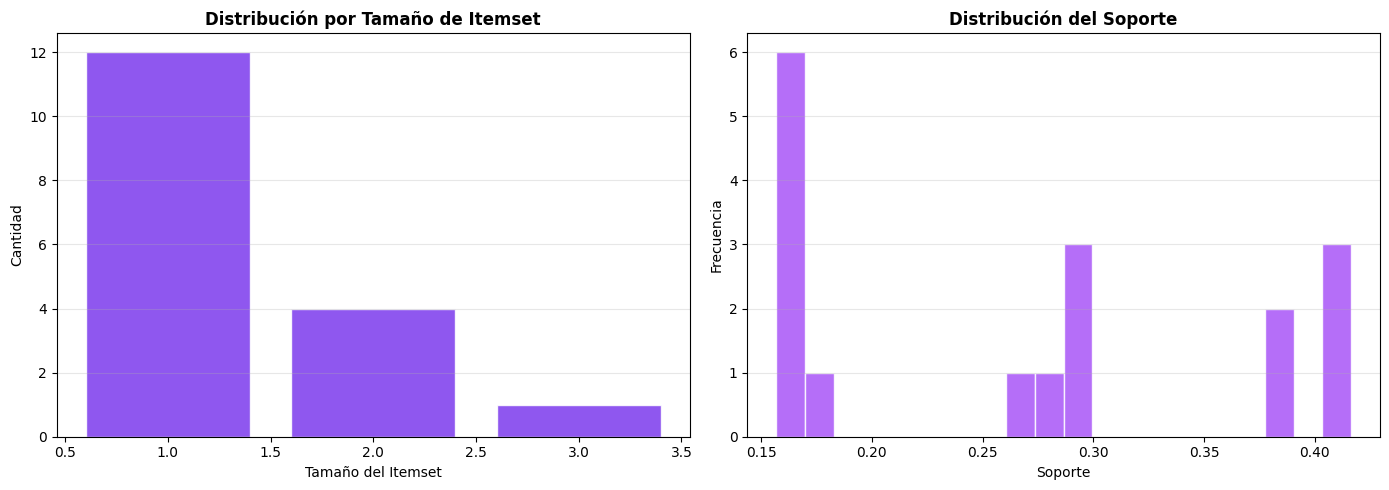

In [3]:
# ─── Celda 3: FP-Growth para itemsets frecuentes ─────────────────────────────
MIN_SUPPORT = 0.10  # Al menos 10% de transacciones
frequent_itemsets = fpgrowth(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets.sort_values('support', ascending=False, inplace=True)

print(f"Itemsets frecuentes encontrados (supp ≥ {MIN_SUPPORT}): {len(frequent_itemsets)}")
print("\nTop 15 itemsets más frecuentes:")
print(frequent_itemsets.head(15).to_string(index=False))

# Distribución por tamaño
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
size_counts = frequent_itemsets['length'].value_counts().sort_index()
axes[0].bar(size_counts.index, size_counts.values, color='#7c3aed', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Tamaño del Itemset')
axes[0].set_ylabel('Cantidad')
axes[0].set_title('Distribución por Tamaño de Itemset', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(frequent_itemsets['support'], bins=20, color='#a855f7', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Soporte')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del Soporte', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Reglas generadas (lift ≥ 1.2): 14

Top 15 reglas por Lift:
antecedents consequents  support  confidence     lift
      Leche   Cafe, Pan  0.26875    0.661538 2.231158
  Cafe, Pan       Leche  0.26875    0.906408 2.231158
       Cafe  Leche, Pan  0.26875    0.661946 2.226899
 Leche, Pan        Cafe  0.26875    0.904121 2.226899
        Pan Cafe, Leche  0.26875    0.645258 2.200369
Cafe, Leche         Pan  0.26875    0.916454 2.200369
    Pañales     Cerveza  0.27650    0.719584 1.902402
    Cerveza     Pañales  0.27650    0.730998 1.902402
       Cafe       Leche  0.29325    0.722291 1.777946
      Leche        Cafe  0.29325    0.721846 1.777946
      Leche         Pan  0.29725    0.731692 1.756764
        Pan       Leche  0.29725    0.713685 1.756764
       Cafe         Pan  0.29650    0.730296 1.753411
        Pan        Cafe  0.29650    0.711885 1.753411


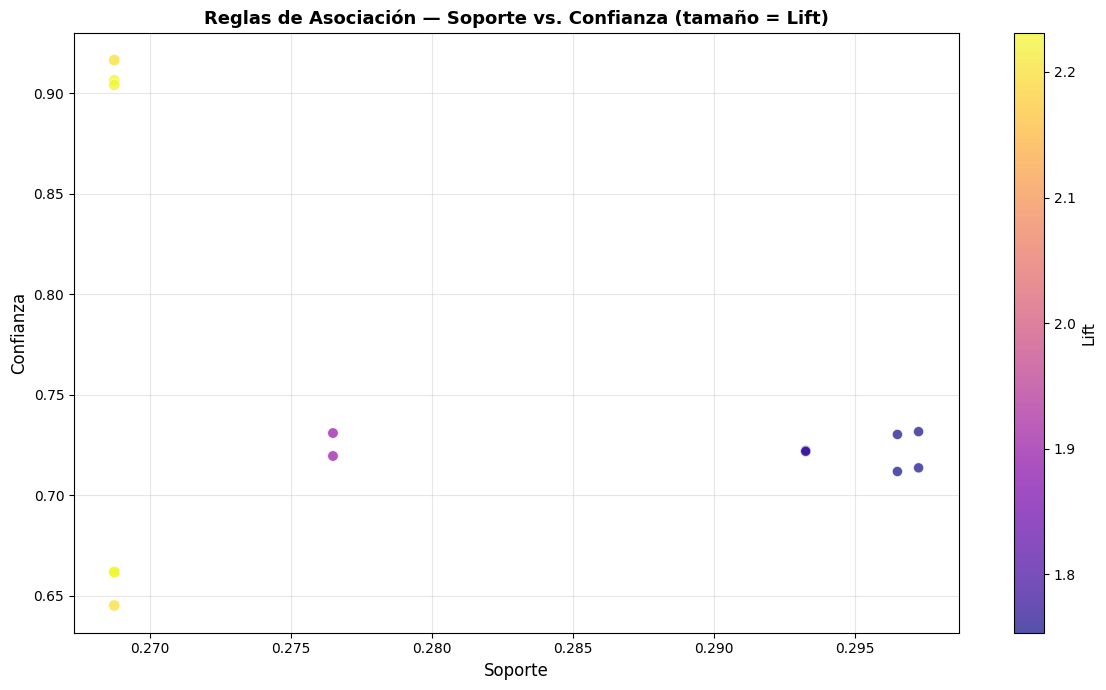

In [4]:
# ─── Celda 4: Generación y filtrado de reglas de asociación ──────────────────
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2, num_itemsets=len(frequent_itemsets))
rules.sort_values('lift', ascending=False, inplace=True)
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f"Reglas generadas (lift ≥ 1.2): {len(rules)}")
print("\nTop 15 reglas por Lift:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

# Visualización Soporte vs. Confianza (burbuja = Lift)
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='plasma',
                     s=rules['lift'] * 30, alpha=0.7, edgecolors='white', linewidths=0.5)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Lift', fontsize=11)
ax.set_xlabel('Soporte', fontsize=12)
ax.set_ylabel('Confianza', fontsize=12)
ax.set_title('Reglas de Asociación — Soporte vs. Confianza (tamaño = Lift)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


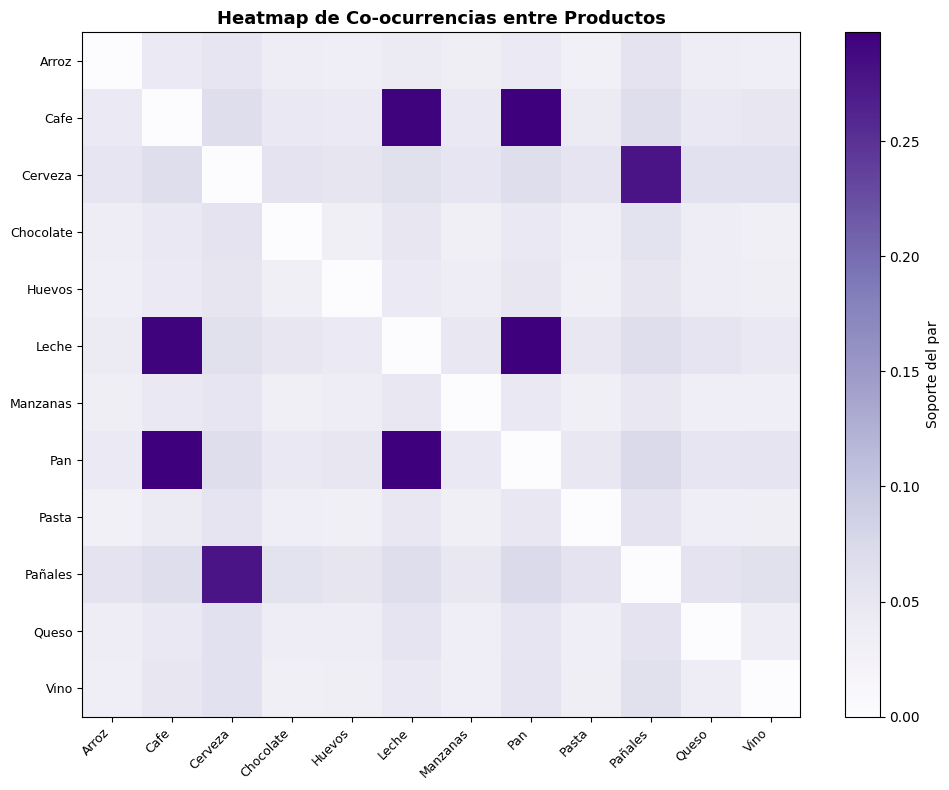

Regla de mayor lift encontrada:
  Leche → Cafe, Pan
  Soporte=0.269, Confianza=0.662, Lift=2.231


In [5]:
# ─── Celda 5: Heatmap de co-ocurrencias ──────────────────────────────────────
import itertools

# Calcular frecuencia de pares
items_list = list(df_encoded.columns)
pair_freq = pd.DataFrame(0.0, index=items_list, columns=items_list)
for col in items_list:
    for col2 in items_list:
        if col != col2:
            pair_freq.loc[col, col2] = (df_encoded[col] & df_encoded[col2]).mean()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pair_freq.values, cmap='Purples', aspect='auto', vmin=0)
ax.set_xticks(range(len(items_list)))
ax.set_yticks(range(len(items_list)))
ax.set_xticklabels(items_list, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(items_list, fontsize=9)
plt.colorbar(im, ax=ax, label='Soporte del par')
ax.set_title('Heatmap de Co-ocurrencias entre Productos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Regla de mayor lift encontrada:")
top = rules.iloc[0]
print(f"  {top['antecedents']} → {top['consequents']}")
print(f"  Soporte={top['support']:.3f}, Confianza={top['confidence']:.3f}, Lift={top['lift']:.3f}")


---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos · Data Mining · Módulo 03</i><br>
    Docente: Santiago A. Zúñiga M. | <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
  </p>
</div>